In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [2]:
data = fetch_california_housing(as_frame=True)

In [3]:
print(data.data.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [7]:
print(data.target_names)

['MedHouseVal']


In [9]:
 x =data.data
 y = data.target

In [11]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [13]:
data.data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [15]:
print(x.shape)
print(y.shape)

(20640, 8)
(20640,)


In [17]:
from sklearn.model_selection import train_test_split

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression

In [23]:
lr = LinearRegression()

In [25]:
lr.fit(x_train,y_train)

LinearRegression()

In [27]:
y_pred = lr.predict(x_test)

In [29]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.575787706032451

<Axes: >

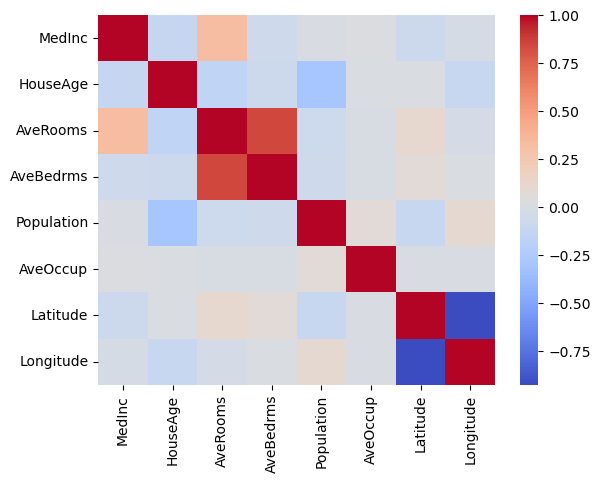

In [31]:
import seaborn as sns
sns.heatmap(data.data.corr(numeric_only=True),cmap='coolwarm')

In [32]:
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import mean_squared_error

degrees = [2,3]
alphas = [0.001, 0.01,0.02,0.025,0.03,0.04, 0.1, 1]
results = []


for degree in degrees:
    
    poly= PolynomialFeatures(degree = degree )

    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)
 
    std =StandardScaler()

    x_train_scaled = std.fit_transform(x_train_poly)
    x_test_scaled = std.transform(x_test_poly)

    
    for alpha in alphas:  
    
        reg1 = Ridge(alpha = alpha)    
        
        reg1.fit(x_train_scaled,y_train)
        
        y_pred_scaled = reg1.predict(x_test_scaled)
        
        r2 = r2_score(y_test,y_pred_scaled) 
        mse = mean_squared_error(y_test,y_pred_scaled)
        results.append([
            degree,
            alpha,
            r2,mse
        ])
results

   
results_df = pd.DataFrame(
    results,
    columns=['degree','Alpha','r2_score','MSE']
)
results_df.sort_values("r2_score",ascending=False)

,degree,Alpha,r2_score,MSE
3,2,0.025,0.671110,0.430980
2,2,0.020,0.670877,0.431286
4,2,0.030,0.670798,0.431389
15,3,1.000,0.670626,0.431615
5,2,0.040,0.669410,0.433208
1,2,0.010,0.666585,0.436910
6,2,0.100,0.659953,0.445601
0,2,0.001,0.649477,0.459329
14,3,0.100,0.644162,0.466293
7,2,1.000,0.639133,0.472883


In [ ]:

alphas = [0.01, 0.1, 1, 10]
results = []

for alpha in alphas:  
    las = Lasso(alpha=alpha,max_iter=10000)
    las.fit(x_train_scaled,y_train)
    y_pred_lasso = las.predict(x_test_scaled)
    r2_score2 =r2_score(y_test,y_pred_lasso)
    results.append([alpha,r2_score2])
    results_df = pd.DataFrame(results,columns=['alpha','R2'])
    results_df.sort_values('R2',ascending=False)

In [ ]:
elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter = 10000
)

In [ ]:
elastic.fit(x_train_scaled,y_train)

In [ ]:
y_pred_elasticnet=elastic.predict(x_test_scaled)

In [ ]:
r2=r2_score(y_test,y_pred_elasticnet)
mse = mean_squared_error(y_test,y_pred_elasticnet)
print(r2,mse)